# 05 Do iPhone Models with More News Attention Have Worse Amazon Rating Scores?

This notebook tells a simple data story with three sources:

- Amazon Electronics listings provide product titles, star ratings, review counts, and prices.
- GDELT provides a 2023 news-attention signal for each iPhone model.
- Wikipedia provides model release years, which help separate newer launch-cycle phones from older long-tail phones.

**Research question:** Do iPhone models with more news attention have worse Amazon rating scores?

The purpose of this university informatics project is to show a clear technology pipeline and a presentable story. The score below is intentionally transparent instead of statistically complex.

`rating_score = weighted_average_rating * review_confidence`

where:

- `weighted_average_rating` gives more influence to listings with more reviews: `log(1 + no_of_ratings)`.
- `review_confidence` penalizes model groups with very little review evidence: `1 - exp(-total_reviews / 500)`.

A model can therefore have a high raw rating but a lower rating score if it appears in only a few weakly reviewed listings. GDELT mentions are treated as media attention, not as a direct measure of product quality.

## Import Libraries

In [1]:
import math
import os
import re
import sys
from pathlib import Path

spark_home = os.environ.get("SPARK_HOME", "/usr/local/spark")
spark_python_path = os.path.join(spark_home, "python")
py4j_zip_path = os.path.join(spark_python_path, "lib", "py4j-0.10.9.7-src.zip")

for path in [spark_python_path, py4j_zip_path]:
    if os.path.exists(path) and path not in sys.path:
        sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

## Spark Context and Session

In [2]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("iphone-amazon-rating-news-attention")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print(sc.version)
print(sc.master)

3.5.0
local[*]


## Chart Style and Output Folder

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120,
})

CHART_DIR = Path("data/analysis_charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)


def save_chart(filename):
    path = CHART_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved {path}")


def add_bar_labels(ax, fmt="{:.2f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=8)

## Load Input Data with PySpark

In [4]:
cleaned_data_file = "data/cleaned-amazon-electronics-sales-2023.csv"
gdelt_file = "data/gdelt-iphone-news-mentions-2023.csv"
wiki_file = "data/wikipedia-iphone-models.csv"

for required_file in [cleaned_data_file, gdelt_file, wiki_file]:
    if not os.path.exists(required_file):
        raise FileNotFoundError(f"{required_file} was not found.")

cleaned_schema = StructType([
    StructField("name", StringType(), True),
    StructField("main_category", StringType(), True),
    StructField("sub_category", StringType(), True),
    StructField("image", StringType(), True),
    StructField("link", StringType(), True),
    StructField("ratings", DoubleType(), True),
    StructField("no_of_ratings", IntegerType(), True),
    StructField("discount_price", DoubleType(), True),
    StructField("actual_price", DoubleType(), True),
])

gdelt_schema = StructType([
    StructField("model_name", StringType(), True),
    StructField("gdelt_mentions_2023", DoubleType(), True),
    StructField("gdelt_query_url", StringType(), True),
    StructField("gdelt_fetch_status", StringType(), True),
])

wiki_schema = StructType([
    StructField("model_name", StringType(), True),
    StructField("initial_os", StringType(), True),
    StructField("release_date", StringType(), True),
    StructField("discontinued_date", StringType(), True),
    StructField("support_ended", StringType(), True),
    StructField("final_os", StringType(), True),
    StructField("support_lifespan_max", StringType(), True),
    StructField("support_lifespan_min", StringType(), True),
    StructField("support_status", StringType(), True),
    StructField("release_year", IntegerType(), True),
])

amazon_df = spark.read.option("header", "true").schema(cleaned_schema).csv(cleaned_data_file)
gdelt_df = spark.read.option("header", "true").schema(gdelt_schema).csv(gdelt_file)
wiki_df = spark.read.option("header", "true").schema(wiki_schema).csv(wiki_file)

print("Amazon rows:", amazon_df.count())
print("GDELT rows:", gdelt_df.count())
print("Wikipedia rows:", wiki_df.count())

Amazon rows: 9411
GDELT rows: 6
Wikipedia rows: 52


## Extract Real iPhone Handset Listings

The Amazon Electronics file contains many accessories. The extraction below keeps titles that look like actual iPhone handsets and rejects obvious cases such as cases, covers, cables, chargers, protectors, adapters, and renewed-store accessories.

In [5]:
wiki_models = (
    wiki_df
    .select("model_name", "release_year", "release_date", "support_status")
    .where(F.col("model_name").rlike("^iPhone"))
    .toPandas()
    .sort_values(["release_year", "model_name"], ascending=[False, False])
)

model_names = wiki_models["model_name"].tolist()
model_names[:10]

['iPhone 17e',
 'iPhone Air',
 'iPhone 17 Pro Max',
 'iPhone 17 Pro',
 'iPhone 17',
 'iPhone 16e',
 'iPhone 16 Pro Max',
 'iPhone 16 Pro',
 'iPhone 16 Plus',
 'iPhone 16']

In [6]:
accessory_terms = [
    "case", "cover", "protector", "tempered", "glass", "guard", "screen", "film",
    "charger", "charging", "cable", "adapter", "earphone", "headphone", "buds",
    "strap", "stand", "holder", "mount", "ring", "lens", "camera protector",
    "skin", "wallet", "sleeve", "back cover", "battery", "power bank",
]

condition_terms = ["renewed", "refurbished", "used", "pre-owned", "unlocked"]


def title_matches_model(title, model):
    title_norm = re.sub(r"[^a-z0-9]+", " ", str(title).lower()).strip()
    model_norm = re.sub(r"[^a-z0-9]+", " ", str(model).lower()).strip()
    return bool(re.search(rf"\b{re.escape(model_norm)}\b", title_norm))


def looks_like_accessory(title):
    title_norm = re.sub(r"[^a-z0-9]+", " ", str(title).lower()).strip()
    return any(re.search(rf"\b{re.escape(term)}\b", title_norm) for term in accessory_terms)


def looks_like_handset(title):
    title_norm = str(title).lower()
    has_storage = bool(re.search(r"\b(16|32|64|128|256|512)\s*gb\b|\b1\s*tb\b", title_norm))
    has_phone_word = "iphone" in title_norm
    return has_phone_word and (has_storage or any(term in title_norm for term in condition_terms))


def extract_model(title):
    if looks_like_accessory(title) or not looks_like_handset(title):
        return None
    for model in model_names:
        if title_matches_model(title, model):
            return model
    return None


amazon_pdf = amazon_df.toPandas()
amazon_pdf["model_name"] = amazon_pdf["name"].apply(extract_model)

iphone_listings = (
    amazon_pdf
    .dropna(subset=["model_name", "ratings", "no_of_ratings"])
    .query("ratings > 0 and no_of_ratings > 0")
    .copy()
)

iphone_listings["review_weight"] = np.log1p(iphone_listings["no_of_ratings"])
iphone_listings["rating_weighted"] = iphone_listings["ratings"] * iphone_listings["review_weight"]

print("Matched handset listings:", len(iphone_listings))
iphone_listings[["model_name", "ratings", "no_of_ratings", "discount_price", "name"]].head(10)

Matched handset listings: 21


,model_name,ratings,no_of_ratings,discount_price,name
780,iPhone 14,4.5,493.0,816.97,Apple iPhone 14 (128 GB) - (Product) RED
1088,iPhone 13,4.6,13932.0,805.87,Apple iPhone 13 (256GB) - Midnight
2057,iPhone 13,4.6,13932.0,705.14,Apple iPhone 13 (128GB) - Starlight
2292,iPhone 12,4.5,30123.0,648.07,Apple iPhone 12 (128GB) - Black
2553,iPhone 12,4.5,30123.0,604.40,Apple iPhone 12 (64GB) - Black
3500,iPhone 12,4.5,30123.0,670.45,Apple iPhone 12 (128GB) - Green
3877,iPhone 14 Pro,4.6,306.0,1376.71,Apple iPhone 14 Pro (128 GB) - Deep Purple
4968,iPhone 12,4.5,30123.0,604.40,Apple iPhone 12 (64GB) - Blue
5785,iPhone 14 Pro,4.6,306.0,1376.71,Apple iPhone 14 Pro (128 GB) - Space Black
5912,iPhone 13,4.6,13932.0,705.14,Apple iPhone 13 (128GB) - Blue


## Build the Model-Level Rating Score

In [7]:
model_summary = (
    iphone_listings
    .groupby("model_name", as_index=False)
    .agg(
        listing_count=("name", "count"),
        average_rating=("ratings", "mean"),
        median_rating=("ratings", "median"),
        total_reviews=("no_of_ratings", "sum"),
        median_reviews=("no_of_ratings", "median"),
        median_discount_price=("discount_price", "median"),
        weighted_rating_sum=("rating_weighted", "sum"),
        review_weight_sum=("review_weight", "sum"),
    )
)

model_summary["weighted_average_rating"] = (
    model_summary["weighted_rating_sum"] / model_summary["review_weight_sum"]
)
model_summary["review_confidence"] = 1 - np.exp(-model_summary["total_reviews"] / 500)
model_summary["rating_score"] = (
    model_summary["weighted_average_rating"] * model_summary["review_confidence"]
)

analysis_df = (
    model_summary
    .merge(gdelt_df.toPandas()[["model_name", "gdelt_mentions_2023"]], on="model_name", how="left")
    .merge(wiki_models[["model_name", "release_year", "support_status"]], on="model_name", how="left")
)

analysis_df["gdelt_mentions_2023"] = analysis_df["gdelt_mentions_2023"].fillna(0)
analysis_df["log_news_attention"] = np.log1p(analysis_df["gdelt_mentions_2023"])
analysis_df["news_rank"] = analysis_df["gdelt_mentions_2023"].rank(ascending=False, method="dense")
analysis_df["rating_score_rank"] = analysis_df["rating_score"].rank(ascending=False, method="dense")
analysis_df["attention_group"] = pd.qcut(
    analysis_df["gdelt_mentions_2023"].rank(method="first"),
    q=min(3, len(analysis_df)),
    labels=["Low attention", "Medium attention", "High attention"],
)

analysis_df = analysis_df.sort_values("gdelt_mentions_2023", ascending=False).reset_index(drop=True)
analysis_df.round(3)

,model_name,listing_count,average_rating,median_rating,total_reviews,median_reviews,median_discount_price,weighted_rating_sum,review_weight_sum,weighted_average_rating,review_confidence,rating_score,gdelt_mentions_2023,release_year,support_status,log_news_attention,news_rank,rating_score_rank,attention_group
0,iPhone 14,2,4.5,4.5,986.0,493.0,827.655,55.823,12.405,4.5,0.861,3.874,14533.0,2022,"Discontinued, still supported",9.584,1.0,4.0,High attention
1,iPhone 14 Pro,3,4.6,4.6,918.0,306.0,1376.710,79.030,17.181,4.6,0.841,3.867,7535.0,2022,"Discontinued, still supported",8.927,2.0,5.0,High attention
2,iPhone 13,6,4.6,4.6,83592.0,13932.0,705.140,263.360,57.252,4.6,1.000,4.600,4294.0,2021,"Discontinued, still supported",8.365,3.0,1.0,Medium attention
3,iPhone 14 Pro Max,3,4.5,4.5,882.0,294.0,1432.670,76.774,17.061,4.5,0.829,3.729,3651.0,2022,"Discontinued, still supported",8.203,4.0,6.0,Medium attention
4,iPhone 12,5,4.5,4.5,150615.0,30123.0,604.400,232.044,51.565,4.5,1.000,4.500,3622.0,2020,"Discontinued, still supported",8.195,5.0,2.0,Low attention
5,iPhone 14 Plus,1,4.5,4.5,314.0,314.0,1018.540,25.887,5.753,4.5,0.466,2.099,1552.0,2022,"Discontinued, still supported",7.348,6.0,7.0,Low attention
6,iPhone,1,4.3,4.3,11058.0,11058.0,77.000,40.037,9.311,4.3,1.000,4.300,0.0,2007,Discontinued and unsupported,0.000,7.0,3.0,Low attention


## Story Result in One Table

In [8]:
story_table = analysis_df[[
    "model_name",
    "release_year",
    "gdelt_mentions_2023",
    "listing_count",
    "total_reviews",
    "weighted_average_rating",
    "review_confidence",
    "rating_score",
    "news_rank",
    "rating_score_rank",
]].copy()

story_table["gdelt_mentions_2023"] = story_table["gdelt_mentions_2023"].astype(int)
story_table.round(3)

,model_name,release_year,gdelt_mentions_2023,listing_count,total_reviews,weighted_average_rating,review_confidence,rating_score,news_rank,rating_score_rank
0,iPhone 14,2022,14533,2,986.0,4.5,0.861,3.874,1.0,4.0
1,iPhone 14 Pro,2022,7535,3,918.0,4.6,0.841,3.867,2.0,5.0
2,iPhone 13,2021,4294,6,83592.0,4.6,1.000,4.600,3.0,1.0
3,iPhone 14 Pro Max,2022,3651,3,882.0,4.5,0.829,3.729,4.0,6.0
4,iPhone 12,2020,3622,5,150615.0,4.5,1.000,4.500,5.0,2.0
5,iPhone 14 Plus,2022,1552,1,314.0,4.5,0.466,2.099,6.0,7.0
6,iPhone,2007,0,1,11058.0,4.3,1.000,4.300,7.0,3.0


## Correlation Snapshot

In [9]:
pearson_corr = analysis_df[["gdelt_mentions_2023", "log_news_attention", "rating_score", "weighted_average_rating"]].corr()
pearson_corr.round(3)

,gdelt_mentions_2023,log_news_attention,rating_score,weighted_average_rating
gdelt_mentions_2023,1.000,0.628,0.115,0.410
log_news_attention,0.628,1.000,-0.122,0.883
rating_score,0.115,-0.122,1.000,-0.026
weighted_average_rating,0.410,0.883,-0.026,1.000


The story is easier to present as an attention-versus-rating contrast than as a formal hypothesis test. The central question for the slides is: **do the models that dominate 2023 news attention land lower on the Amazon rating score axis?**

## Chart 1: Which iPhone Models Got the Most News Attention?

saved data/analysis_charts/01_news_attention_by_model.png


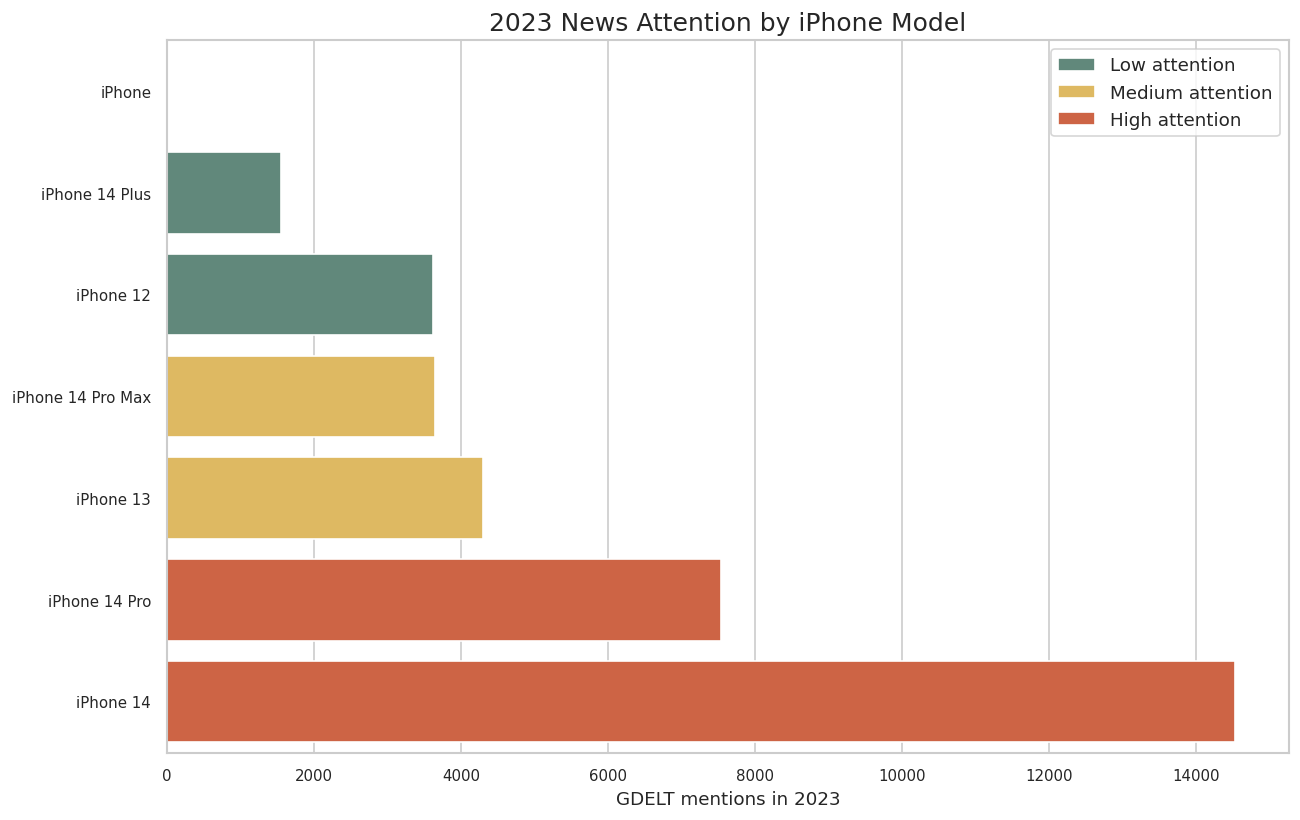

In [10]:
attention_order = analysis_df.sort_values("gdelt_mentions_2023", ascending=True)

plt.figure(figsize=(11, 7))
ax = sns.barplot(
    data=attention_order,
    x="gdelt_mentions_2023",
    y="model_name",
    hue="attention_group",
    dodge=False,
    palette=["#5B8E7D", "#F2C14E", "#E4572E"],
)
ax.set_title("2023 News Attention by iPhone Model")
ax.set_xlabel("GDELT mentions in 2023")
ax.set_ylabel("")
ax.legend(title="")
save_chart("01_news_attention_by_model.png")
plt.show()

## Chart 2: Amazon Rating Score by Model

saved data/analysis_charts/02_rating_score_by_model.png


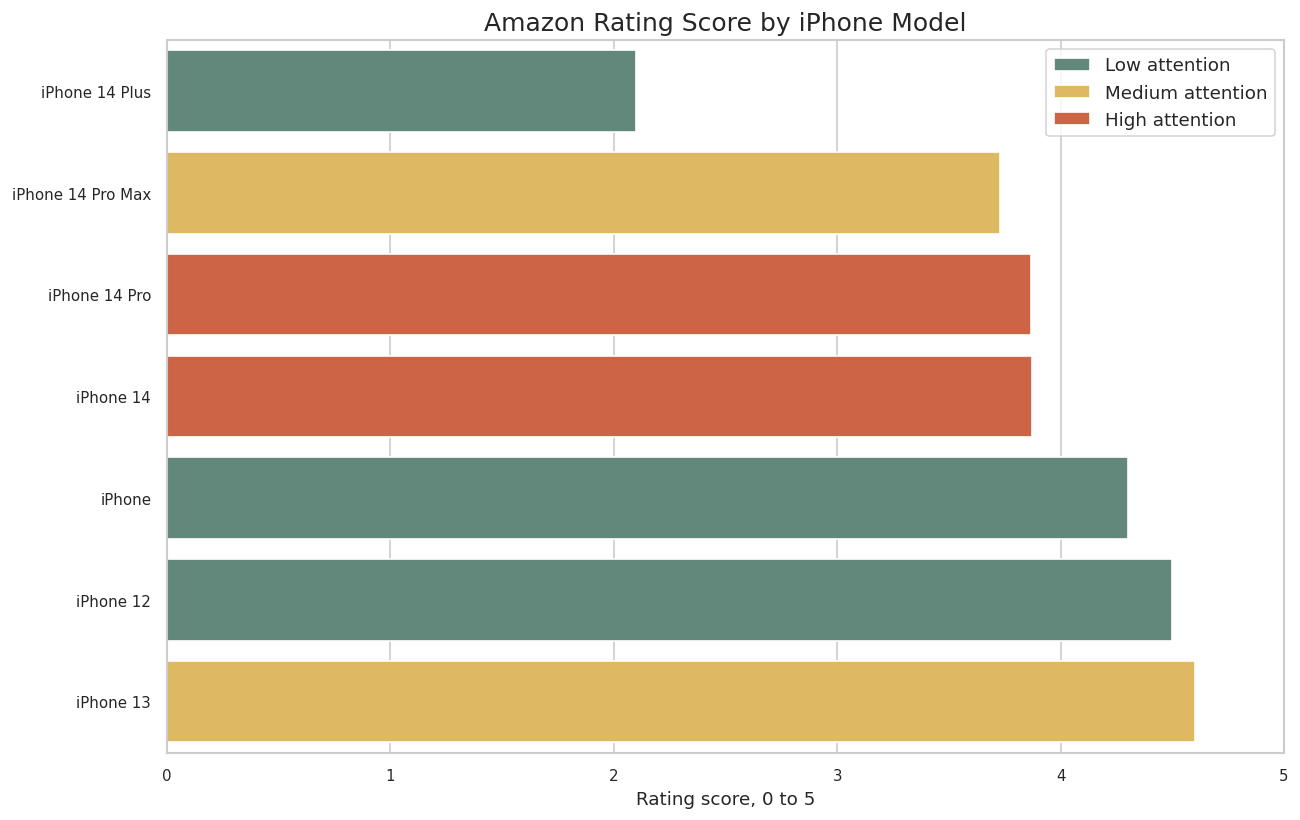

In [11]:
rating_order = analysis_df.sort_values("rating_score", ascending=True)

plt.figure(figsize=(11, 7))
ax = sns.barplot(
    data=rating_order,
    x="rating_score",
    y="model_name",
    hue="attention_group",
    dodge=False,
    palette=["#5B8E7D", "#F2C14E", "#E4572E"],
)
ax.set_title("Amazon Rating Score by iPhone Model")
ax.set_xlabel("Rating score, 0 to 5")
ax.set_ylabel("")
ax.set_xlim(0, 5)
ax.legend(title="")
save_chart("02_rating_score_by_model.png")
plt.show()

## Chart 3: The Main Story Scatterplot

saved data/analysis_charts/03_attention_vs_rating_score_scatter.png


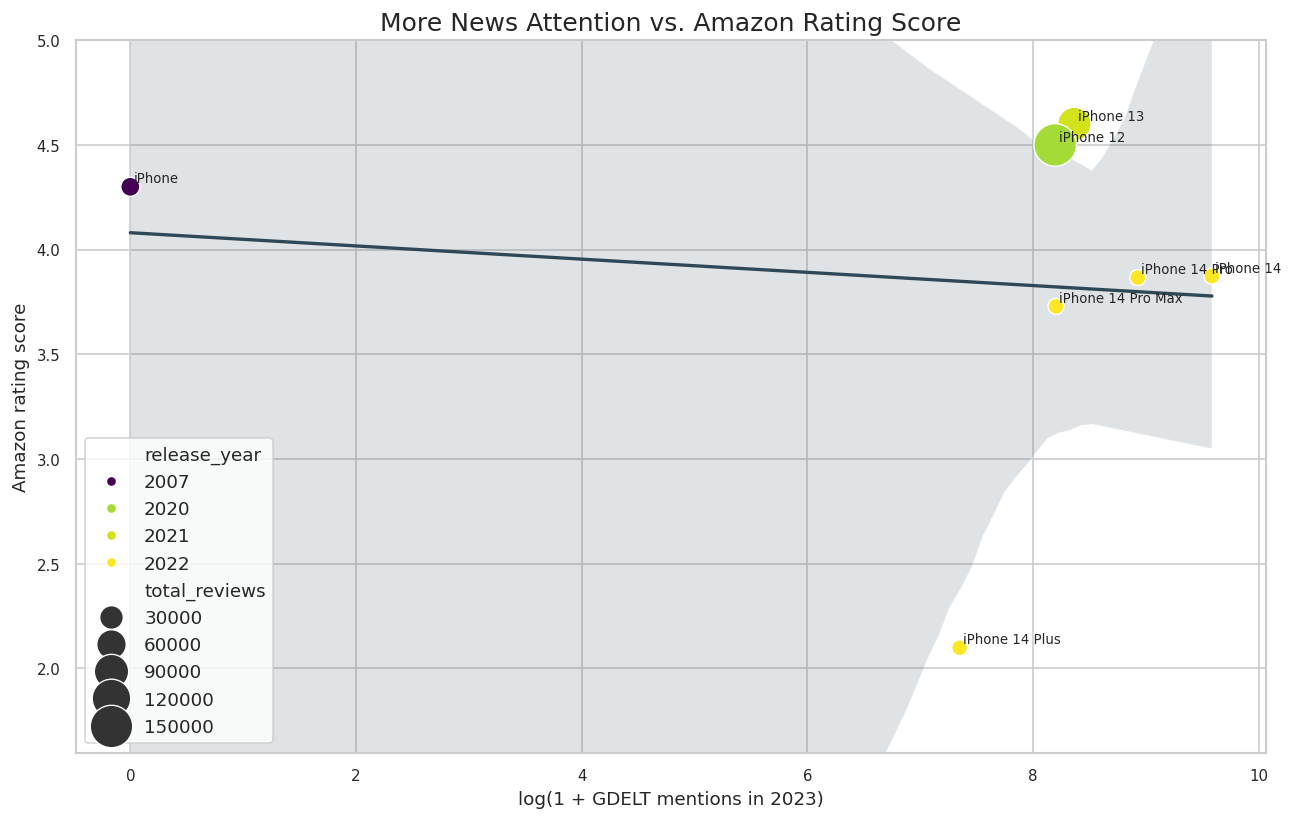

In [12]:
plt.figure(figsize=(11, 7))
ax = sns.regplot(
    data=analysis_df,
    x="log_news_attention",
    y="rating_score",
    scatter=False,
    color="#2F4858",
    line_kws={"linewidth": 2},
)
sns.scatterplot(
    data=analysis_df,
    x="log_news_attention",
    y="rating_score",
    size="total_reviews",
    hue="release_year",
    palette="viridis",
    sizes=(90, 650),
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)
for _, row in analysis_df.iterrows():
    ax.text(row["log_news_attention"] + 0.03, row["rating_score"] + 0.02, row["model_name"], fontsize=8)
ax.set_title("More News Attention vs. Amazon Rating Score")
ax.set_xlabel("log(1 + GDELT mentions in 2023)")
ax.set_ylabel("Amazon rating score")
ax.set_ylim(max(0, analysis_df["rating_score"].min() - 0.5), 5)
save_chart("03_attention_vs_rating_score_scatter.png")
plt.show()

## Chart 4: Attention-Rating Quadrants

saved data/analysis_charts/04_attention_rating_quadrants.png


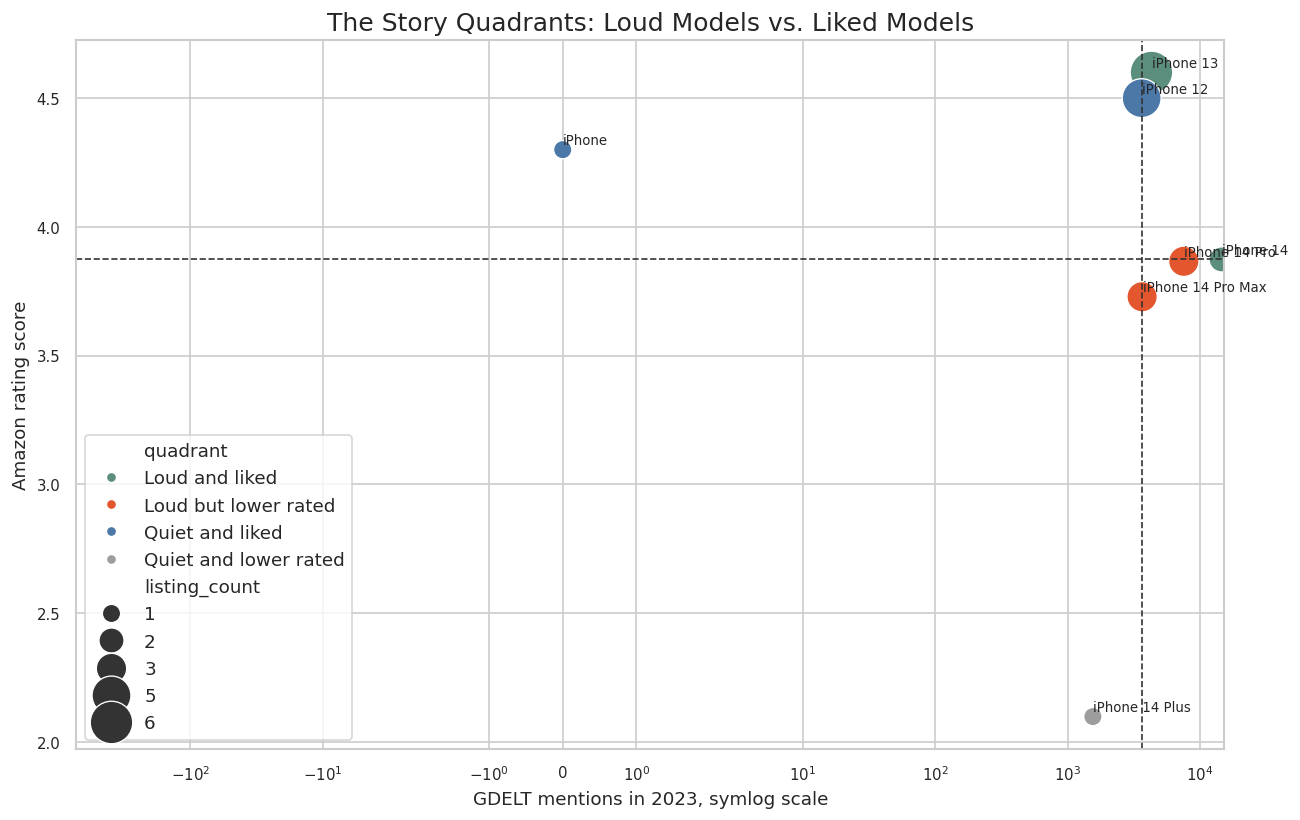

In [13]:
attention_median = analysis_df["gdelt_mentions_2023"].median()
score_median = analysis_df["rating_score"].median()

analysis_df["quadrant"] = np.select(
    [
        (analysis_df["gdelt_mentions_2023"] >= attention_median) & (analysis_df["rating_score"] >= score_median),
        (analysis_df["gdelt_mentions_2023"] >= attention_median) & (analysis_df["rating_score"] < score_median),
        (analysis_df["gdelt_mentions_2023"] < attention_median) & (analysis_df["rating_score"] >= score_median),
    ],
    ["Loud and liked", "Loud but lower rated", "Quiet and liked"],
    default="Quiet and lower rated",
)

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=analysis_df,
    x="gdelt_mentions_2023",
    y="rating_score",
    hue="quadrant",
    size="listing_count",
    sizes=(120, 650),
    palette={
        "Loud and liked": "#5B8E7D",
        "Loud but lower rated": "#E4572E",
        "Quiet and liked": "#4C78A8",
        "Quiet and lower rated": "#9D9D9D",
    },
    edgecolor="white",
    linewidth=0.8,
)
ax.axvline(attention_median, color="#333333", linestyle="--", linewidth=1)
ax.axhline(score_median, color="#333333", linestyle="--", linewidth=1)
for _, row in analysis_df.iterrows():
    ax.text(row["gdelt_mentions_2023"] * 1.01, row["rating_score"] + 0.02, row["model_name"], fontsize=8)
ax.set_xscale("symlog")
ax.set_title("The Story Quadrants: Loud Models vs. Liked Models")
ax.set_xlabel("GDELT mentions in 2023, symlog scale")
ax.set_ylabel("Amazon rating score")
save_chart("04_attention_rating_quadrants.png")
plt.show()

## Chart 5: Rank Mismatch Between Attention and Rating Score

saved data/analysis_charts/05_rank_mismatch_attention_vs_rating.png


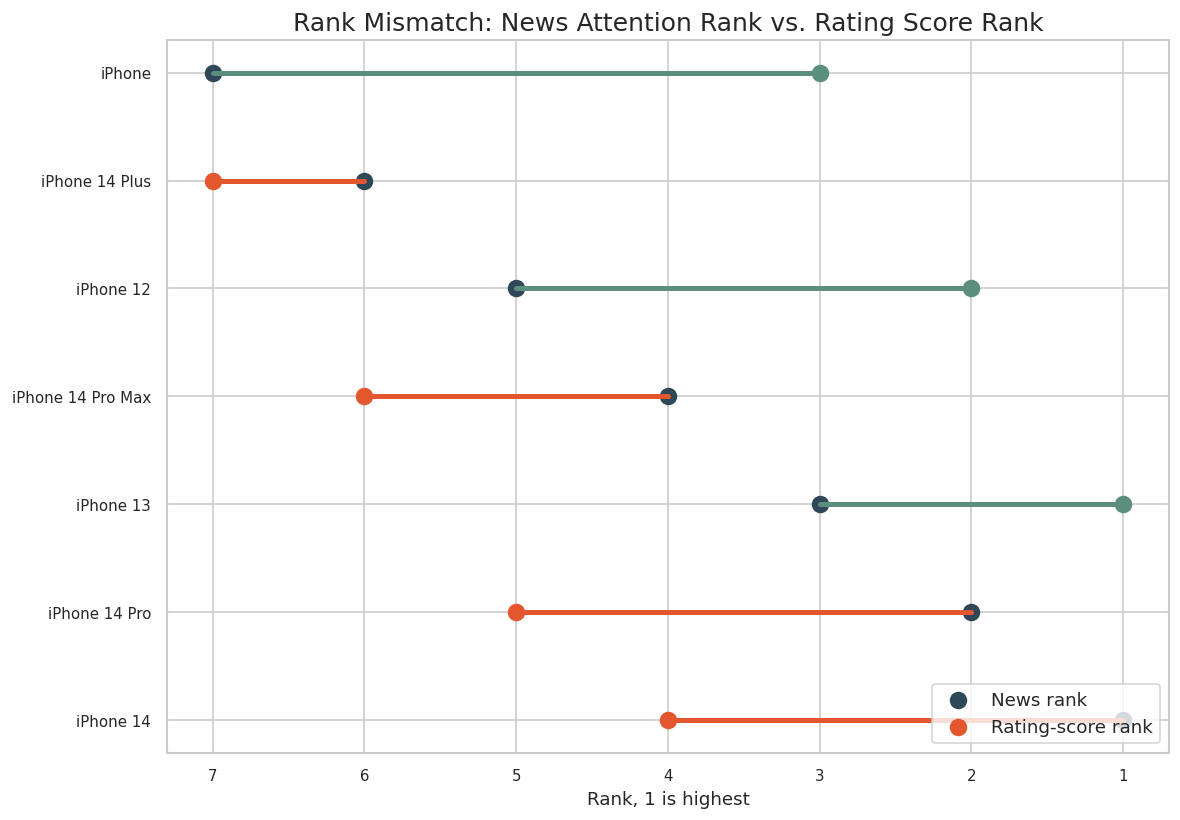

In [14]:
rank_df = analysis_df.sort_values("news_rank").copy()
rank_df["rank_gap"] = rank_df["rating_score_rank"] - rank_df["news_rank"]

plt.figure(figsize=(10, 7))
ax = plt.gca()
for _, row in rank_df.iterrows():
    color = "#E4572E" if row["rank_gap"] > 0 else "#5B8E7D"
    ax.plot([row["news_rank"], row["rating_score_rank"]], [row["model_name"], row["model_name"]], color=color, linewidth=3)
    ax.scatter(row["news_rank"], row["model_name"], color="#2F4858", s=90, label="News rank" if row.name == rank_df.index[0] else "")
    ax.scatter(row["rating_score_rank"], row["model_name"], color=color, s=90, label="Rating-score rank" if row.name == rank_df.index[0] else "")
ax.invert_xaxis()
ax.set_title("Rank Mismatch: News Attention Rank vs. Rating Score Rank")
ax.set_xlabel("Rank, 1 is highest")
ax.set_ylabel("")
ax.legend(loc="lower right")
save_chart("05_rank_mismatch_attention_vs_rating.png")
plt.show()

## Chart 6: Rating Score Components

saved data/analysis_charts/06_rating_score_components.png


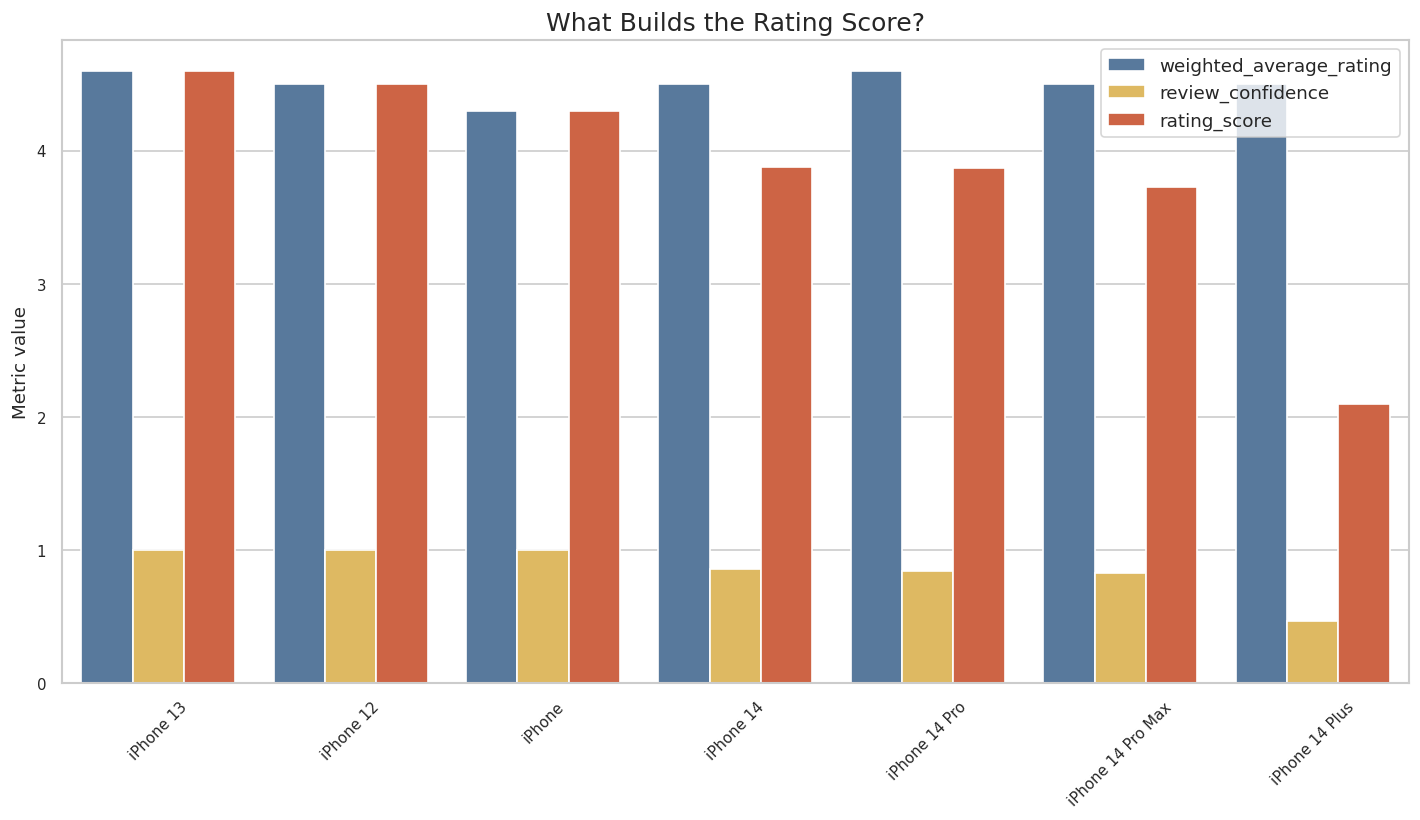

In [15]:
component_df = analysis_df.sort_values("rating_score", ascending=False).melt(
    id_vars=["model_name"],
    value_vars=["weighted_average_rating", "review_confidence", "rating_score"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=component_df,
    x="model_name",
    y="value",
    hue="metric",
    palette=["#4C78A8", "#F2C14E", "#E4572E"],
)
ax.set_title("What Builds the Rating Score?")
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="")
save_chart("06_rating_score_components.png")
plt.show()

## Chart 7: Listing-Level Rating Distribution

saved data/analysis_charts/07_listing_rating_distribution.png


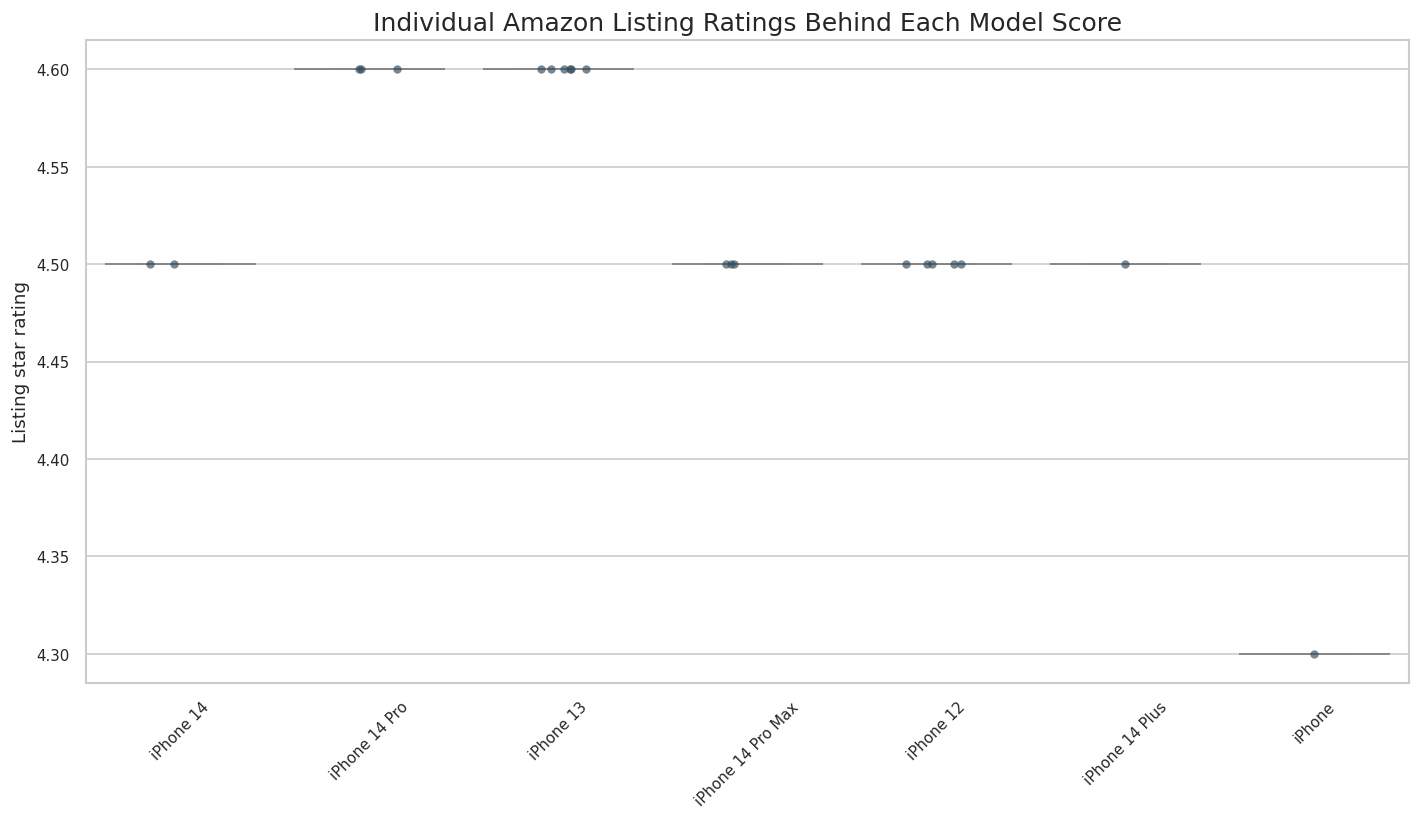

In [16]:
models_for_distribution = analysis_df.sort_values("gdelt_mentions_2023", ascending=False)["model_name"].tolist()
dist_df = iphone_listings[iphone_listings["model_name"].isin(models_for_distribution)].copy()

plt.figure(figsize=(12, 7))
ax = sns.boxplot(
    data=dist_df,
    x="model_name",
    y="ratings",
    order=models_for_distribution,
    color="#D9E8E3",
)
sns.stripplot(
    data=dist_df,
    x="model_name",
    y="ratings",
    order=models_for_distribution,
    color="#2F4858",
    alpha=0.65,
    jitter=0.18,
    size=5,
    ax=ax,
)
ax.set_title("Individual Amazon Listing Ratings Behind Each Model Score")
ax.set_xlabel("")
ax.set_ylabel("Listing star rating")
ax.tick_params(axis="x", rotation=45)
save_chart("07_listing_rating_distribution.png")
plt.show()

## Chart 8: Review Volume Gives Some Models a Louder Amazon Voice

saved data/analysis_charts/08_review_volume_and_listing_count.png


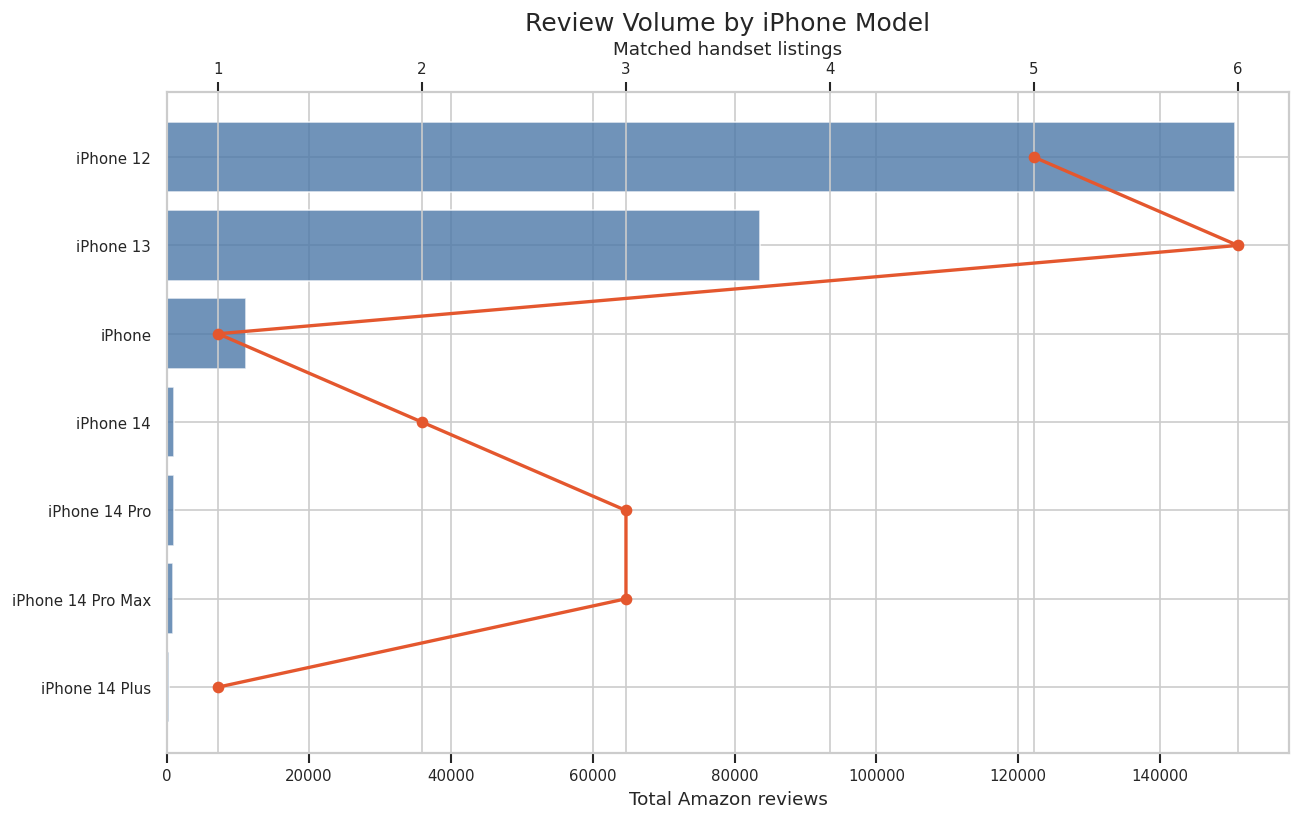

In [17]:
review_order = analysis_df.sort_values("total_reviews", ascending=True)

fig, ax1 = plt.subplots(figsize=(11, 7))
ax1.barh(review_order["model_name"], review_order["total_reviews"], color="#4C78A8", alpha=0.8)
ax1.set_xlabel("Total Amazon reviews")
ax1.set_ylabel("")
ax1.set_title("Review Volume by iPhone Model")
ax2 = ax1.twiny()
ax2.plot(review_order["listing_count"], review_order["model_name"], color="#E4572E", marker="o", linewidth=2)
ax2.set_xlabel("Matched handset listings")
save_chart("08_review_volume_and_listing_count.png")
plt.show()

## Chart 9: Newer Models Get More News Attention

saved data/analysis_charts/09_release_year_vs_news_attention.png


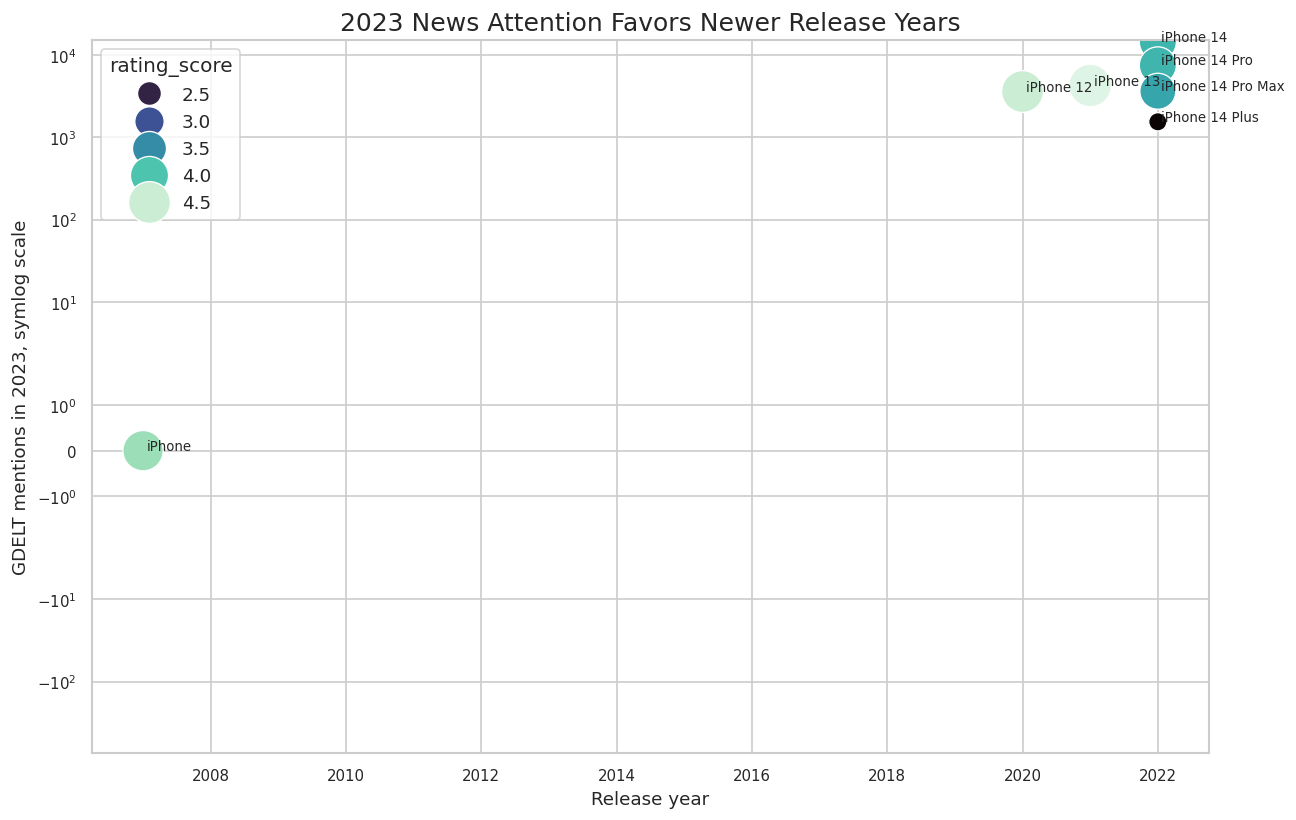

In [18]:
plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=analysis_df,
    x="release_year",
    y="gdelt_mentions_2023",
    size="rating_score",
    hue="rating_score",
    palette="mako",
    sizes=(120, 650),
    edgecolor="white",
    linewidth=0.8,
)
for _, row in analysis_df.iterrows():
    ax.text(row["release_year"] + 0.05, row["gdelt_mentions_2023"] * 1.02, row["model_name"], fontsize=8)
ax.set_yscale("symlog")
ax.set_title("2023 News Attention Favors Newer Release Years")
ax.set_xlabel("Release year")
ax.set_ylabel("GDELT mentions in 2023, symlog scale")
save_chart("09_release_year_vs_news_attention.png")
plt.show()

## Chart 10: Price Context for the Rating Story

saved data/analysis_charts/10_price_context_rating_score.png


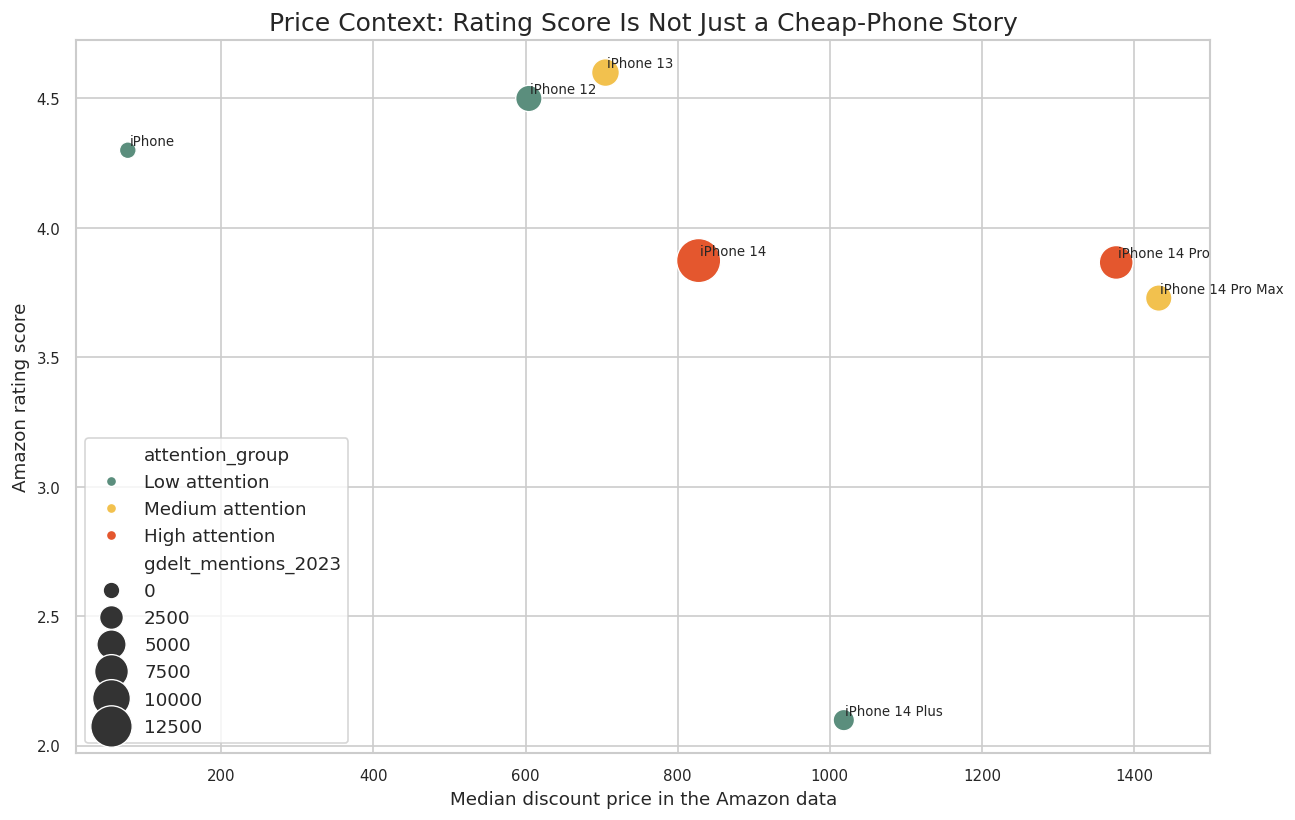

In [19]:
price_df = analysis_df.dropna(subset=["median_discount_price"]).copy()

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=price_df,
    x="median_discount_price",
    y="rating_score",
    size="gdelt_mentions_2023",
    hue="attention_group",
    palette=["#5B8E7D", "#F2C14E", "#E4572E"],
    sizes=(100, 700),
    edgecolor="white",
    linewidth=0.8,
)
for _, row in price_df.iterrows():
    ax.text(row["median_discount_price"] + 2, row["rating_score"] + 0.02, row["model_name"], fontsize=8)
ax.set_title("Price Context: Rating Score Is Not Just a Cheap-Phone Story")
ax.set_xlabel("Median discount price in the Amazon data")
ax.set_ylabel("Amazon rating score")
save_chart("10_price_context_rating_score.png")
plt.show()

## Chart 11: Attention Groups Compared

saved data/analysis_charts/11_attention_group_comparison.png


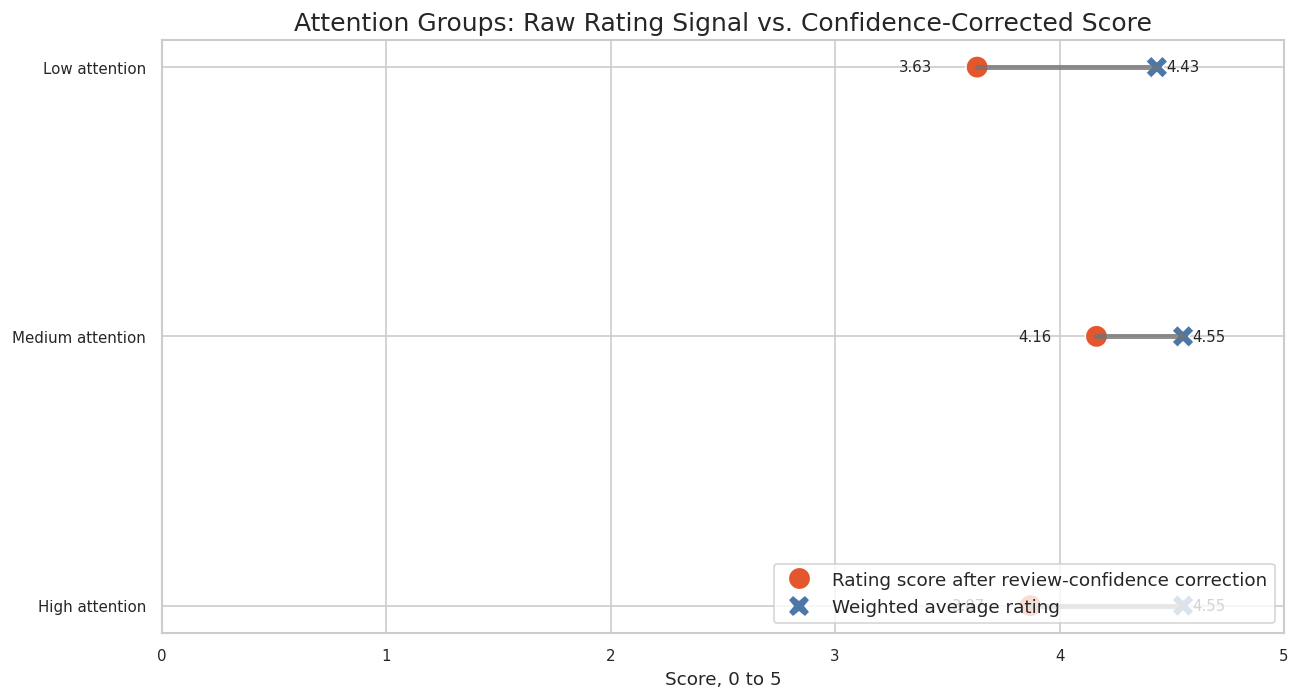

In [20]:
group_summary = (
    analysis_df
    .groupby("attention_group", observed=True)
    .agg(
        mean_rating_score=("rating_score", "mean"),
        mean_weighted_rating=("weighted_average_rating", "mean"),
        mean_reviews=("total_reviews", "mean"),
        models=("model_name", "count"),
    )
    .reset_index()
)

plot_group = group_summary.melt(
    id_vars=["attention_group"],
    value_vars=["mean_rating_score", "mean_weighted_rating"],
    var_name="metric",
    value_name="value",
)

attention_group_order = ["Low attention", "Medium attention", "High attention"]
metric_labels = {
    "mean_weighted_rating": "Weighted average rating",
    "mean_rating_score": "Rating score after review-confidence correction",
}
plot_group["metric_label"] = plot_group["metric"].map(metric_labels)
plot_group["attention_group"] = pd.Categorical(
    plot_group["attention_group"],
    categories=attention_group_order,
    ordered=True,
)
plot_group = plot_group.sort_values(["attention_group", "metric_label"])

fig, ax = plt.subplots(figsize=(11, 6))
for group_name, group_data in plot_group.groupby("attention_group", observed=True):
    values = group_data.set_index("metric")["value"]
    ax.plot(
        [values["mean_weighted_rating"], values["mean_rating_score"]],
        [group_name, group_name],
        color="#737373",
        linewidth=3,
        alpha=0.8,
    )

sns.scatterplot(
    data=plot_group,
    x="value",
    y="attention_group",
    hue="metric_label",
    style="metric_label",
    s=180,
    palette={
        "Weighted average rating": "#4C78A8",
        "Rating score after review-confidence correction": "#E4572E",
    },
    edgecolor="white",
    linewidth=0.9,
    ax=ax,
)
for _, row in plot_group.iterrows():
    label_offset = 0.04 if row["metric"] == "mean_weighted_rating" else -0.35
    ax.text(
        row["value"] + label_offset,
        row["attention_group"],
        f"{row['value']:.2f}",
        va="center",
        fontsize=9,
    )
ax.set_title("Attention Groups: Raw Rating Signal vs. Confidence-Corrected Score")
ax.set_xlabel("Score, 0 to 5")
ax.set_ylabel("")
ax.set_xlim(0, 5)
ax.legend(title="", loc="lower right")
save_chart("11_attention_group_comparison.png")
plt.show()

## Chart 12: Heatmap of the Story Metrics

saved data/analysis_charts/12_story_metric_heatmap.png


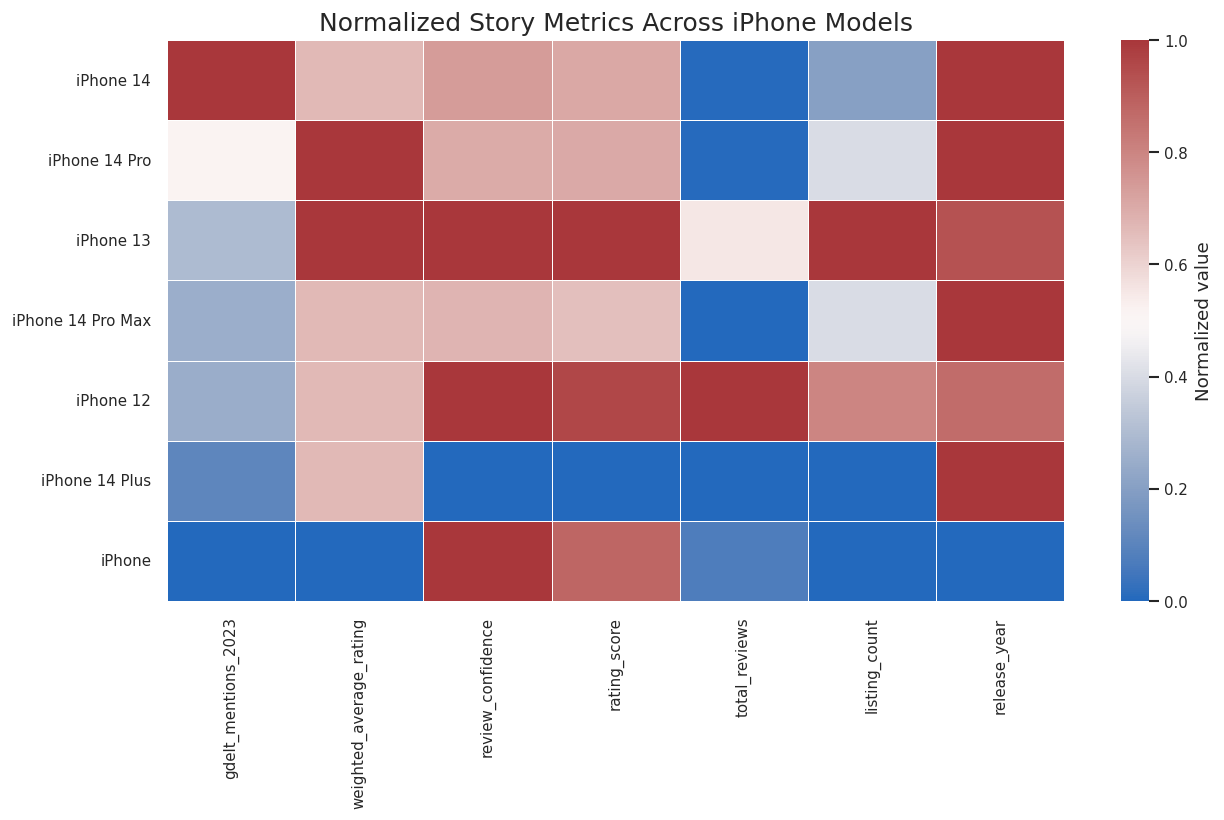

In [21]:
heatmap_df = analysis_df.set_index("model_name")[[
    "gdelt_mentions_2023",
    "weighted_average_rating",
    "review_confidence",
    "rating_score",
    "total_reviews",
    "listing_count",
    "release_year",
]].copy()

normalized_heatmap = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())
normalized_heatmap = normalized_heatmap.fillna(0)

plt.figure(figsize=(11, 7))
ax = sns.heatmap(
    normalized_heatmap.sort_values("gdelt_mentions_2023", ascending=False),
    cmap="vlag",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Normalized value"},
)
ax.set_title("Normalized Story Metrics Across iPhone Models")
ax.set_xlabel("")
ax.set_ylabel("")
save_chart("12_story_metric_heatmap.png")
plt.show()

## Presentation Takeaways

In [22]:
highest_attention = analysis_df.sort_values("gdelt_mentions_2023", ascending=False).head(3)
lowest_scores = analysis_df.sort_values("rating_score", ascending=True).head(3)
high_attention_score = analysis_df.loc[
    analysis_df["attention_group"].eq("High attention"), "rating_score"
].mean()
low_attention_score = analysis_df.loc[
    analysis_df["attention_group"].eq("Low attention"), "rating_score"
].mean()

print("Most mentioned iPhone models in 2023:")
for _, row in highest_attention.iterrows():
    print(f"- {row['model_name']}: {int(row['gdelt_mentions_2023'])} mentions, rating score {row['rating_score']:.2f}")

print("\nLowest Amazon rating scores:")
for _, row in lowest_scores.iterrows():
    print(f"- {row['model_name']}: rating score {row['rating_score']:.2f}, {int(row['gdelt_mentions_2023'])} mentions")

print("\nAttention group comparison:")
print(f"- High-attention average rating score: {high_attention_score:.2f}")
print(f"- Low-attention average rating score: {low_attention_score:.2f}")
print(f"- Difference, high minus low: {high_attention_score - low_attention_score:.2f}")

Most mentioned iPhone models in 2023:
- iPhone 14: 14533 mentions, rating score 3.87
- iPhone 14 Pro: 7535 mentions, rating score 3.87
- iPhone 13: 4294 mentions, rating score 4.60

Lowest Amazon rating scores:
- iPhone 14 Plus: rating score 2.10, 1552 mentions
- iPhone 14 Pro Max: rating score 3.73, 3651 mentions
- iPhone 14 Pro: rating score 3.87, 7535 mentions

Attention group comparison:
- High-attention average rating score: 3.87
- Low-attention average rating score: 3.63
- Difference, high minus low: 0.24


## Story Conclusion

The notebook supports a presentation story that high news attention is not automatically a sign of better Amazon satisfaction. The most visible models in 2023 are often newer and more discussed, but their Amazon rating scores can be pulled down by mixed listing ratings, uncertain review evidence, or the stronger expectations placed on recent flagship models.

For slides, the strongest visual sequence is:

1. Show the news-attention bar chart to establish which models were loud in 2023.
2. Show the rating-score bar chart to reveal that attention and Amazon satisfaction do not move together perfectly.
3. Use the scatterplot and quadrant chart as the main answer to the research question.
4. Use the component, distribution, and review-volume charts to explain how the rating score was built.

**Short answer:** in this dataset, more news attention does not guarantee better Amazon rating scores. The story leans toward the opposite: the loudest iPhone models are not always the best-rated ones on Amazon.

In [23]:
spark.stop()